# Analiza zbioru jadalności grzybów
<p>
    Projekt wykonany w zespole 3-osobowym
</p>

## Wstęp
<p>
    Celem naszego projektu było przeanalizowanie zbioru jadalności grzybów pod względem klasyfikacji i asocjacji, przy użyciu metod redukcji wymiarów.
</p>

<p>
    Zbiór danych został pobrany z kaggle: <a href="https://www.kaggle.com/datasets/uciml/mushroom-classification">https://www.kaggle.com/datasets/uciml/mushroom-classification</a>.<br>
    Zawiera 22 kolumny zawierające informacje o grzybie, tj. kolor kapelusza, rozmiar trzonu czy miejsce występowania.<br>
    Oraz 1 kolumnę z informacją, czy dany grzyb jest jadalny lub trujący.<br>
    Wszystkie kolumny są kategoryczne.
</p>

## Wykorzystane techniki i biblioteki
<ul>
    <li><strong>One-Hot Encoder</strong> - wykorzystany do zamiany kolumn kategorycznych na macierz binarną, do testowania działania klasyfikatora oraz reguł asocjacyjnych. Każda unikalna kategoria zostaje zamieniona na osobną binarną kolumnę (0/1).</li>
    <li><strong>Label Encoder</strong> - wykorzystany do zamiany kolumn kategorycznych na kolumny numeryczne, do testowania działania klasyfikatora. Każdej kategorii w kolumnie przypisywana jest unikalna liczba całkowita, zmieniając kategorie tekstowe na numeryczne. (sklearn.preprocessing)</li>
    <li><strong>PCA (Principal Component Analysis)</strong> - wykorzystana do redukcji wymiarów. PCA przekształca oryginalne cechy w nowe, nieskorelowane składowe główne. Działa na zasadzie największej wariancji ogólnej. Nie zakłada istnienia ukrytych danych. (sklearn.decomposition)</li>
    <li><strong>SVD (Singular Value Decomposition)</strong> - wykorzystana do redukcji wymiarów. SVD dekomponuje zbiór danych na komponenty o malejącej istotności. Umożliwia identyfikację ukrytych danych. (sklearn.decomposition)</li>
    <li><strong>Drzewo decyzyjne</strong> - wykorzystane do klasyfikacji. Model ma strukturę drzewa, w którym kolejne węzły reprezentują warunki podziału danych. (sklearn.tree)</li>
    <li><strong>GridSearch</strong> - wykorzystany do znalezienia optymalnych parametrów klasyfikatora. GridSearch polega na automatycznym przeszukiwaniu wszystkich kombinacji zadanych wartości parametrów i ocenie ich jakości. (sklearn.model_selection)</li>
    <li><strong>Asocjacja Apriori</strong> - wykorzystana do odnalezienia reguł asocjacji. Algorytm Apriori identyfikuje częste zbiory elementów i generuje reguły typu „jeśli–to”. Wykorzystuje miary takie jak wsparcie, ufność i lift. (mlxtend.frequent_patterns)</li>
</ul>

<p>
    Do danych użyto biblioteki Pandas.<br>
    NumPy został wykorzystany w celach matematycznych.<br>
    Do generowania wykresów użyto MatPlotLib.PyPlot oraz Seaborn.<br>
    Do oceniania jakoś klasyfikatora użyto Sklearn.metrics.<br>
</p>

## Spis treści
<ol start="0">
    <li>Wstępny import bibliotek i wczytanie zbioru danych</li>
    <li>Przetwarzanie danych za pomocą One-Hot Encodingu oraz redukcja PCA i SVD</li>
    <li>Przetwarzanie danych za pomocą Label Encodingu oraz redukcja PCA i SVD</li>
    <li>Dobór zbioru danych i parametrów drzewa decyzyjnego</li>
    <li>Utworzenie klasyfikatora i jego analiza</li>
    <li>Wyszukiwanie reguł asocjacyjnych</li>
</ol>

# 0. Import bibliotek, wczytanie zbioru danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

In [2]:
df = pd.read_csv("mushrooms.csv")

In [40]:
df.isna().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [3]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


# 1. Zakodowanie danych przy pomocy One-Hot Encodingu 

Pełny słownik mapowań skrótów na pełne nazwy

In [4]:
mappings = {
    "class": {"e": "edible", "p": "poisonous"},

    "cap-shape": {"b": "bell", "c": "conical", "x": "convex", "f": "flat", "k": "knobbed", "s": "sunken"},

    "cap-surface": {"f": "fibrous", "g": "grooves", "y": "scaly", "s": "smooth"},

    "cap-color": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "r": "green", "p": "pink",
                  "u": "purple", "e": "red", "w": "white", "y": "yellow"},

    "bruises": {"t": "bruises", "f": "no"},

    "odor": {"a": "almond", "l": "anise", "c": "creosote", "y": "fishy", "f": "foul", "m": "musty",
             "n": "none", "p": "pungent", "s": "spicy"},

    "gill-attachment": {"a": "attached", "d": "descending", "f": "free", "n": "notched"},

    "gill-spacing": {"c": "close", "w": "crowded", "d": "distant"},

    "gill-size": {"b": "broad", "n": "narrow"},

    "gill-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "g": "gray", "r": "green",
                   "o": "orange", "p": "pink", "u": "purple", "e": "red", "w": "white", "y": "yellow"},

    "stalk-shape": {"e": "enlarging", "t": "tapering"},

    "stalk-root": {"b": "bulbous", "c": "club", "u": "cup", "e": "equal", "z": "rhizomorphs",
                   "r": "rooted", "?": "missing"},

    "stalk-surface-above-ring": {"f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth"},

    "stalk-surface-below-ring": {"f": "fibrous", "y": "scaly", "k": "silky", "s": "smooth"},

    "stalk-color-above-ring": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "o": "orange",
                               "p": "pink", "e": "red", "w": "white", "y": "yellow"},

    "stalk-color-below-ring": {"n": "brown", "b": "buff", "c": "cinnamon", "g": "gray", "o": "orange",
                               "p": "pink", "e": "red", "w": "white", "y": "yellow"},

    "veil-type": {"p": "partial", "u": "universal"},

    "veil-color": {"n": "brown", "o": "orange", "w": "white", "y": "yellow"},

    "ring-number": {"n": "none", "o": "one", "t": "two"},

    "ring-type": {"c": "cobwebby", "e": "evanescent", "f": "flaring", "l": "large", "n": "none",
                  "p": "pendant", "s": "sheathing", "z": "zone"},

    "spore-print-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "r": "green",
                          "o": "orange", "u": "purple", "w": "white", "y": "yellow"},

    "population": {"a": "abundant", "c": "clustered", "n": "numerous", "s": "scattered",
                   "v": "several", "y": "solitary"},

    "habitat": {"g": "grasses", "l": "leaves", "m": "meadows", "p": "paths",
                "u": "urban", "w": "waste", "d": "woods"}
}

Funkcja zmieniająca nazwy kolumn po One-Hot Encodingu

In [5]:
def rename_columns(columns, mappings):
    new_cols = []
    for col in columns:
        if "_" not in col or col == "class":
            new_cols.append(col)
            continue

        feature, code = col.split("_", 1)

        if feature in mappings and code in mappings[feature]:
            new_cols.append(f"{feature}_{mappings[feature][code]}")
        else:
            new_cols.append(col)

    return new_cols

Stworzenie kompletnego binarnego datasetu z poprawnymi nazwami

In [6]:
# Oddzielamy kolumnę class
class_col = df[["class"]]
features = df.drop(columns=["class"])

# One-Hot Encoding
encoded = pd.get_dummies(features)

# Zamiana True/False → 0/1
encoded = encoded.astype(int)

# Zmiana nazw kolumn na pełne nazwy
encoded.columns = rename_columns(encoded.columns, mappings)

# Dodanie kolumny class z powrotem
mushrooms_onehot = pd.concat([class_col, encoded], axis=1)

# Zmapowanie nazw klas
mushrooms_onehot["class"] = mushrooms_onehot["class"].map({"e": "edible", "p": "poisonous"})

In [7]:
mushrooms_onehot.head()

,class,cap-shape_bell,cap-shape_conical,cap-shape_flat,cap-shape_knobbed,cap-shape_sunken,cap-shape_convex,cap-surface_fibrous,cap-surface_grooves,cap-surface_smooth,...,population_scattered,population_several,population_solitary,habitat_woods,habitat_grasses,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste
0,poisonous,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
1,edible,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,edible,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,poisonous,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,edible,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0


## Sprawdzenie PCA na zbiorze zakodowanym One-Hot Encoderem

In [8]:
features = mushrooms_onehot.drop(columns=["class"])

pca = PCA()
pca.fit(features)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

Wykres osypiska

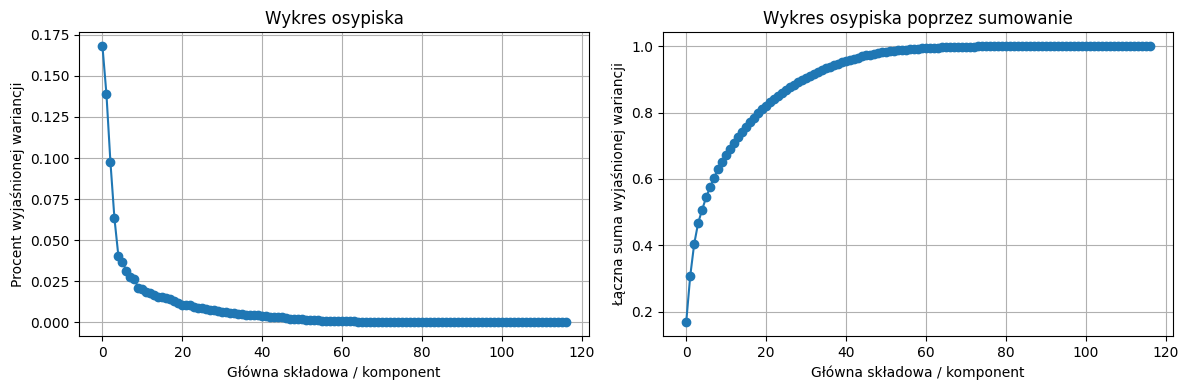

In [9]:
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. Wykres osypiska (pojedyncze komponenty)
ax[0].plot(var_exp, marker="o")
ax[0].set_xlabel("Główna składowa / komponent")
ax[0].set_ylabel("Procent wyjaśnionej wariancji")
ax[0].set_title("Wykres osypiska")
ax[0].grid(True)

# 2. Wykres skumulowanej wariancji
ax[1].plot(np.cumsum(var_exp), marker="o")
ax[1].set_xlabel("Główna składowa / komponent")
ax[1].set_ylabel("Łączna suma wyjaśnionej wariancji")
ax[1].set_title("Wykres osypiska poprzez sumowanie")
ax[1].grid(True)

plt.tight_layout()
plt.show()


Kryterium wyjaśnionej wariancji

In [10]:
cum_var = pca.explained_variance_ratio_.cumsum()
n80 = np.argmax(cum_var >= 0.80) + 1
print("Liczba komponentów dla 80% wariancji:", n80)

Liczba komponentów dla 80% wariancji: 20


Reguła Kaisera 

In [11]:
eigenvalues = pca.explained_variance_
kaiser = sum(eigenvalues > 1)
print("Komponenty wg reguły Kaisera:", kaiser)

Komponenty wg reguły Kaisera: 3


<p>
    Zgodnie z regułą Kaisera zalecane jest użycie trzech składowych, jednak według wykresu osypiska ich suma wyjaśniałaby jedynie około <strong>40% wariancji</strong>. 
</p>

<p>
    W celu zachowania dużej części informacji na potrzeby klasyfikatora wybrano liczbę kolumn wskazaną przez kryterium wyjaśnionej wariancji. Podobnie zachowano się w przypadku pozostałych zbiorów.
</p>

## Sprawdzenie SVD na zbiorze zakodowanym One-Hot Encoderem

In [12]:
svd = TruncatedSVD(n_components=features.shape[1] - 1)
svd.fit(features)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",116
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


Wykres osypiska

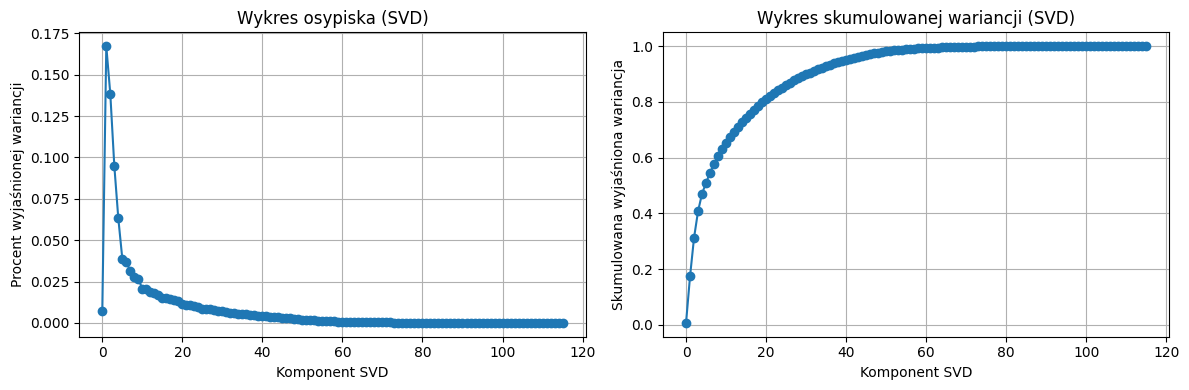

In [13]:
var_exp = svd.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. Wykres osypiska
ax[0].plot(var_exp, marker="o")
ax[0].set_xlabel("Komponent SVD")
ax[0].set_ylabel("Procent wyjaśnionej wariancji")
ax[0].set_title("Wykres osypiska (SVD)")
ax[0].grid(True)

# 2. Wykres skumulowanej wariancji
ax[1].plot(np.cumsum(var_exp), marker="o")
ax[1].set_xlabel("Komponent SVD")
ax[1].set_ylabel("Skumulowana wyjaśniona wariancja")
ax[1].set_title("Wykres skumulowanej wariancji (SVD)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

Kryterium wyjaśnionej wariancji

In [14]:
cum_var = np.cumsum(var_exp)
n80 = np.argmax(cum_var >= 0.80) + 1
print("Liczba komponentów SVD dla 80% wariancji:", n80)


Liczba komponentów SVD dla 80% wariancji: 21


## Zastosowanie PCA dla 20 składowych głównych dla zbioru One-Hot Encoded

In [15]:
pca = PCA(n_components=20)
principal_components = pca.fit_transform(features)

# Tworzymy nazwy kolumn: GS1, GS2, ..., GS20
columns = [f"GS{i}" for i in range(1, 21)]

# Tworzymy DataFrame z wynikami PCA
pca_onehot = pd.DataFrame(data=principal_components, columns=columns)

# Dodajemy etykiety klas
pca_onehot["class"] = mushrooms_onehot["class"]

In [16]:
pca_onehot.head()

,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,...,GS12,GS13,GS14,GS15,GS16,GS17,GS18,GS19,GS20,class
0,0.996245,-0.946892,-0.802493,1.267016,-0.984733,-0.202130,-0.627629,0.917816,-0.168588,0.944735,...,0.705918,-0.085946,-0.286715,-0.653434,-0.342997,0.518657,0.280747,0.432067,0.172860,poisonous
1,1.441733,-0.164154,-1.068175,1.490404,-0.573606,-0.228371,-0.146374,0.156965,0.691502,-0.332898,...,-0.234843,0.192294,0.407798,0.058067,0.086686,0.049685,-0.007611,-0.140539,-0.614002,edible
2,1.524085,-0.408746,-0.853172,1.685729,-0.214971,0.298378,-0.508842,0.002269,0.422888,-0.263408,...,-0.451755,0.169241,0.160230,0.284232,0.254047,0.161377,-0.410234,-0.315321,-0.569217,edible
3,1.151800,-0.675820,-0.629840,1.440281,-1.231740,-0.041621,0.327279,0.631125,-0.739247,0.722837,...,-0.140423,-0.125978,-0.570152,-0.585598,-0.516507,0.312740,0.196414,0.317333,0.601447,poisonous
4,0.617503,-0.996143,-1.725882,-1.428404,-0.193594,-0.572471,0.251348,0.249390,0.485667,-0.692119,...,-0.404462,-0.083313,-0.569771,-0.417150,-0.363751,0.174933,-0.302345,0.059210,-0.690690,edible


## Zastosowanie SVD dla 21 komponentów na zbiorze One-Hot Encoded

In [17]:
# SVD na 21 komponentów
svd = TruncatedSVD(n_components=21)
svd_components = svd.fit_transform(features)

# Tworzymy nazwy kolumn: GS1, GS2, ..., GS21
columns = [f"GS{i}" for i in range(1, 22)]

# Tworzymy DataFrame z wynikami SVD
svd_onehot = pd.DataFrame(data=svd_components, columns=columns)

# Dodajemy etykiety klas
svd_onehot["class"] = mushrooms_onehot["class"]

In [18]:
svd_onehot.head()

,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,...,GS13,GS14,GS15,GS16,GS17,GS18,GS19,GS20,GS21,class
0,3.197375,-0.955191,-0.959942,0.798784,1.298081,-0.984371,-0.145082,-0.621251,0.904258,-0.119528,...,0.710480,-0.094870,-0.281692,-0.677694,0.332145,0.545954,0.239962,0.417926,0.133234,poisonous
1,3.282901,-1.414045,-0.187251,1.082095,1.528853,-0.518491,-0.203766,-0.144609,0.112469,0.700863,...,-0.262518,0.205703,0.391618,0.111614,-0.034750,0.037555,0.015161,-0.124907,-0.599369,edible
2,3.118393,-1.503147,-0.441409,0.819192,1.702046,-0.170116,0.307446,-0.507489,-0.035124,0.415072,...,-0.470740,0.181167,0.148119,0.382226,-0.108955,0.145845,-0.394454,-0.312963,-0.585614,edible
3,3.204334,-1.112518,-0.687627,0.631259,1.473117,-1.216316,0.027944,0.333964,0.631044,-0.721872,...,-0.121380,-0.131154,-0.563907,-0.773589,0.179530,0.335095,0.160098,0.298728,0.589558,poisonous
4,3.285090,-0.577116,-1.009344,1.785107,-1.382770,-0.185184,-0.566105,0.251514,0.232572,0.510408,...,-0.420671,-0.073777,-0.587167,-0.533541,0.046015,0.164941,-0.291685,0.073997,-0.661498,edible


# 2. Zakodowanie danych przy pomocy Label Encodingu 

In [19]:
mushrooms_label = df.copy()

label_encoders = {}

for col in mushrooms_label.columns:
    if col != "class" and mushrooms_label[col].dtype == "object":
        le = LabelEncoder()
        mushrooms_label[col] = le.fit_transform(mushrooms_label[col])
        label_encoders[col] = le



In [20]:
mushrooms_label

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,e,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,e,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,p,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,e,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8120,e,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8121,e,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8122,p,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


## Sprawdzenie PCA na zbiorze zakodowanym Label Encoderem

In [21]:
features = mushrooms_label.drop(columns=["class"])

pca = PCA()
pca.fit(features)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

Wykres osypiska

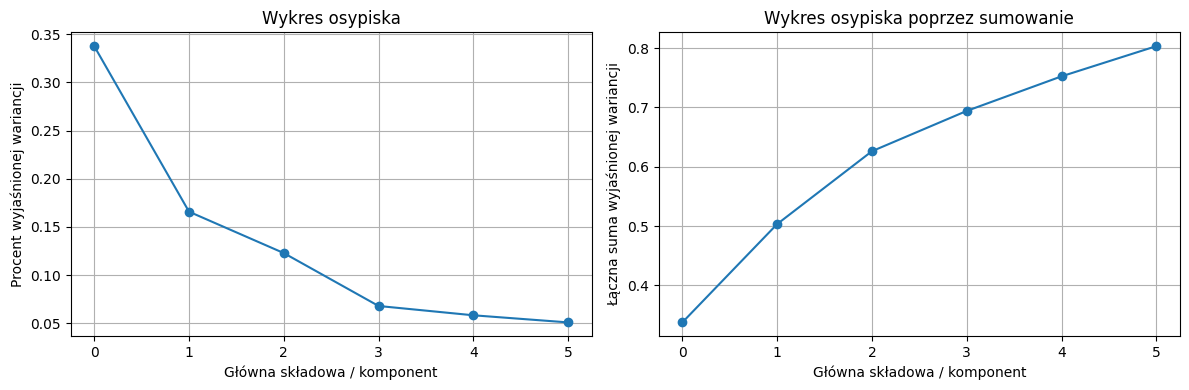

In [41]:
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Wykres osypiska
ax[0].plot(var_exp, marker="o")
ax[0].set_xlabel("Główna składowa / komponent")
ax[0].set_ylabel("Procent wyjaśnionej wariancji")
ax[0].set_title("Wykres osypiska")
ax[0].grid(True)

# Wykres skumulowanej wariancji
ax[1].plot(np.cumsum(var_exp), marker="o")
ax[1].set_xlabel("Główna składowa / komponent")
ax[1].set_ylabel("Łączna suma wyjaśnionej wariancji")
ax[1].set_title("Wykres osypiska poprzez sumowanie")
ax[1].grid(True)

plt.tight_layout()
plt.show()

Procent wyjaśnionej wariancji

In [42]:
var_exp = pca.explained_variance_ratio_

cum_var = np.cumsum(var_exp)
n80 = np.argmax(cum_var >= 0.80) + 1
print("Liczba komponentów dla 80% wariancji:", n80)

Liczba komponentów dla 80% wariancji: 6


Reguła Kaisera

In [43]:
eigenvalues = pca.explained_variance_
kaiser = sum(eigenvalues > 1)
print("Komponenty wg reguły Kaisera:", kaiser)

Komponenty wg reguły Kaisera: 6


## Sprawdzenie SVD na zbiorze zakodowanym Label Encoderem

In [25]:
svd = TruncatedSVD(n_components=features.shape[1] - 1)
svd.fit(features)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",21
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


Wykres osypiska

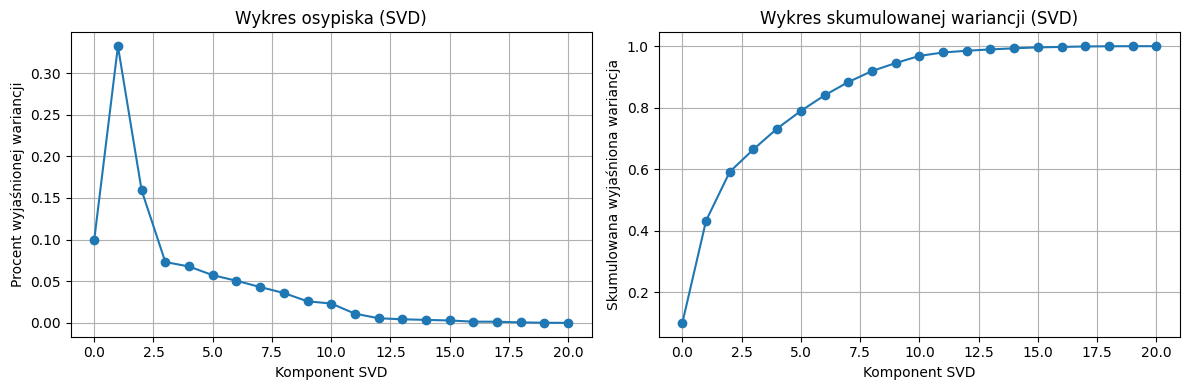

In [26]:
var_exp = svd.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. Wykres osypiska
ax[0].plot(var_exp, marker="o")
ax[0].set_xlabel("Komponent SVD")
ax[0].set_ylabel("Procent wyjaśnionej wariancji")
ax[0].set_title("Wykres osypiska (SVD)")
ax[0].grid(True)

# 2. Wykres skumulowanej wariancji
ax[1].plot(np.cumsum(var_exp), marker="o")
ax[1].set_xlabel("Komponent SVD")
ax[1].set_ylabel("Skumulowana wyjaśniona wariancja")
ax[1].set_title("Wykres skumulowanej wariancji (SVD)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

Kryterium wyjaśnionej wariancji

In [27]:
cum_var = np.cumsum(var_exp)
n80 = np.argmax(cum_var >= 0.80) + 1
print("Liczba komponentów SVD dla 80% wariancji:", n80)

Liczba komponentów SVD dla 80% wariancji: 7


## Zastosowanie PCA dla 6 składowych głównych na zbiorze Label Encoded

In [28]:
pca = PCA(n_components=6)
principal_components = pca.fit_transform(features)

# Tworzymy nazwy kolumn: GS1, GS2, ..., GS6
columns = [f"GS{i}" for i in range(1, 7)]

# Tworzymy DataFrame z wynikami PCA
pca_label = pd.DataFrame(data=principal_components, columns=columns)

# Dodajemy etykiety klas
pca_label["class"] = mushrooms_onehot["class"]

In [29]:
pca_label

,GS1,GS2,GS3,GS4,GS5,GS6,class
0,-0.228207,-0.345472,1.424425,-1.246722,2.088737,2.645915,poisonous
1,1.936561,4.796912,3.511668,-1.245720,0.551144,-0.283909,edible
2,1.654173,2.464362,3.880827,1.222505,1.043965,-2.052608,edible
3,1.252026,1.679664,3.565488,0.586997,0.679516,2.792790,poisonous
4,-1.581220,-1.002043,1.255760,-1.970625,0.070293,3.301132,edible
...,...,...,...,...,...,...,...
8119,6.469823,-2.308511,-0.588111,1.118114,0.617045,1.426498,edible
8120,6.525909,-2.280695,-1.431399,0.329901,0.274762,1.946724,edible
8121,1.860507,0.470244,-1.190212,-0.306579,0.364383,0.053368,edible
8122,-7.293068,-1.251693,1.241976,0.781739,-1.592310,0.043870,poisonous


## Zastosowanie SVD dla 7 komponentów na zbiorze Label Encoded

In [30]:
# SVD na 7 komponentów
svd = TruncatedSVD(n_components=7)
svd_components = svd.fit_transform(features)

# Tworzymy nazwy kolumn: GS1, GS2, ..., GS7
columns = [f"GS{i}" for i in range(1, 8)]

# Tworzymy DataFrame z wynikami SVD
svd_label = pd.DataFrame(data=svd_components, columns=columns)

# Dodajemy etykiety klas
svd_label["class"] = mushrooms_onehot["class"]

In [31]:
svd_label

,GS1,GS2,GS3,GS4,GS5,GS6,GS7,class
0,15.625226,-0.639965,0.382975,-0.171200,-1.239340,2.515024,2.423593,poisonous
1,14.925690,1.696607,5.766056,-1.064753,-1.132304,0.768465,-0.734504,edible
2,14.879618,1.347157,3.552335,-3.201608,1.843226,-0.038062,-1.481252,edible
3,17.419193,0.620641,3.130293,0.290628,0.451686,1.302011,2.470993,poisonous
4,13.384270,-1.746144,-0.595277,-2.395268,-1.567150,-0.356828,3.725297,edible
...,...,...,...,...,...,...,...,...
8119,13.812724,6.321533,-2.561479,-1.105793,1.377793,0.143320,1.821838,edible
8120,14.919716,6.272161,-2.571737,1.394723,0.072922,0.810068,1.688129,edible
8121,11.412488,2.069609,-0.186128,-0.972820,-0.059181,-0.243842,0.627635,edible
8122,14.641892,-7.651835,-0.428588,0.569282,0.617201,-1.417019,0.076237,poisonous


# Podsumowanie procesu redukcji wymiaru

<p>
  W celu zmaksymalizowania procesu testowania doboru zmiennych klasyfikatora zastosowano dwa rodzaje kodowania zmiennych kategorycznych:
  <strong>One-Hot Encoding</strong> oraz <strong>Label Encoding</strong>.
  Na każdym z tak przygotowanych zbiorów danych przeprowadzono redukcję wymiarów z użyciem dwóch algorytmów:
  <strong>PCA (Principal Component Analysis)</strong> oraz <strong>SVD (Truncated Singular Value Decomposition)</strong>.
  Dla każdego z tych podejść przyjęto wspólny próg wyjaśnionej wariancji równy <strong>80%</strong>, co pozwoliło na
  określenie minimalnej liczby komponentów i głównych składowych niezbędnych do zachowania większości informacji zawartej w danych.
</p>

<p>
  Uzyskane wyniki redukcji wymiarów dla różnych metod kodowania i algorytmów przedstawiają się następująco:
</p>

<ol>
  <li>
    <strong>One-Hot Encoding:</strong>
    <ul>
      <li>PCA: <strong>20</strong> składowych głównych</li>
      <li>SVD: <strong>21</strong> komponentów</li>
    </ul>
  </li>

  <li>
    <strong>Label Encoding:</strong>
    <ul>
      <li>PCA: <strong>6</strong> składowych głównych</li>
      <li>SVD: <strong>7</strong> komponentów</li>
    </ul>
  </li>
</ol>


One‑Hot Encoding + PCA

In [32]:
pca_onehot.head()

,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,...,GS12,GS13,GS14,GS15,GS16,GS17,GS18,GS19,GS20,class
0,0.996245,-0.946892,-0.802493,1.267016,-0.984733,-0.202130,-0.627629,0.917816,-0.168588,0.944735,...,0.705918,-0.085946,-0.286715,-0.653434,-0.342997,0.518657,0.280747,0.432067,0.172860,poisonous
1,1.441733,-0.164154,-1.068175,1.490404,-0.573606,-0.228371,-0.146374,0.156965,0.691502,-0.332898,...,-0.234843,0.192294,0.407798,0.058067,0.086686,0.049685,-0.007611,-0.140539,-0.614002,edible
2,1.524085,-0.408746,-0.853172,1.685729,-0.214971,0.298378,-0.508842,0.002269,0.422888,-0.263408,...,-0.451755,0.169241,0.160230,0.284232,0.254047,0.161377,-0.410234,-0.315321,-0.569217,edible
3,1.151800,-0.675820,-0.629840,1.440281,-1.231740,-0.041621,0.327279,0.631125,-0.739247,0.722837,...,-0.140423,-0.125978,-0.570152,-0.585598,-0.516507,0.312740,0.196414,0.317333,0.601447,poisonous
4,0.617503,-0.996143,-1.725882,-1.428404,-0.193594,-0.572471,0.251348,0.249390,0.485667,-0.692119,...,-0.404462,-0.083313,-0.569771,-0.417150,-0.363751,0.174933,-0.302345,0.059210,-0.690690,edible


One‑Hot Encoding + SVD

In [33]:
svd_onehot.head()

,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,...,GS13,GS14,GS15,GS16,GS17,GS18,GS19,GS20,GS21,class
0,3.197375,-0.955191,-0.959942,0.798784,1.298081,-0.984371,-0.145082,-0.621251,0.904258,-0.119528,...,0.710480,-0.094870,-0.281692,-0.677694,0.332145,0.545954,0.239962,0.417926,0.133234,poisonous
1,3.282901,-1.414045,-0.187251,1.082095,1.528853,-0.518491,-0.203766,-0.144609,0.112469,0.700863,...,-0.262518,0.205703,0.391618,0.111614,-0.034750,0.037555,0.015161,-0.124907,-0.599369,edible
2,3.118393,-1.503147,-0.441409,0.819192,1.702046,-0.170116,0.307446,-0.507489,-0.035124,0.415072,...,-0.470740,0.181167,0.148119,0.382226,-0.108955,0.145845,-0.394454,-0.312963,-0.585614,edible
3,3.204334,-1.112518,-0.687627,0.631259,1.473117,-1.216316,0.027944,0.333964,0.631044,-0.721872,...,-0.121380,-0.131154,-0.563907,-0.773589,0.179530,0.335095,0.160098,0.298728,0.589558,poisonous
4,3.285090,-0.577116,-1.009344,1.785107,-1.382770,-0.185184,-0.566105,0.251514,0.232572,0.510408,...,-0.420671,-0.073777,-0.587167,-0.533541,0.046015,0.164941,-0.291685,0.073997,-0.661498,edible


Label Encoding + PCA

In [34]:
pca_label.head()

,GS1,GS2,GS3,GS4,GS5,GS6,class
0,-0.228207,-0.345472,1.424425,-1.246722,2.088737,2.645915,poisonous
1,1.936561,4.796912,3.511668,-1.245720,0.551144,-0.283909,edible
2,1.654173,2.464362,3.880827,1.222505,1.043965,-2.052608,edible
3,1.252026,1.679664,3.565488,0.586997,0.679516,2.792790,poisonous
4,-1.581220,-1.002043,1.255760,-1.970625,0.070293,3.301132,edible


Label Encoding + SVD

In [35]:
svd_label.head()

,GS1,GS2,GS3,GS4,GS5,GS6,GS7,class
0,15.625226,-0.639965,0.382975,-0.171200,-1.239340,2.515024,2.423593,poisonous
1,14.925690,1.696607,5.766056,-1.064753,-1.132304,0.768465,-0.734504,edible
2,14.879618,1.347157,3.552335,-3.201608,1.843226,-0.038062,-1.481252,edible
3,17.419193,0.620641,3.130293,0.290628,0.451686,1.302011,2.470993,poisonous
4,13.384270,-1.746144,-0.595277,-2.395268,-1.567150,-0.356828,3.725297,edible


# 3. Wybranie najlepszego zbioru do klasyfikatora

In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree

Rozdzielenie danych

In [37]:
X_pca_onehot = pca_onehot.iloc[:,:-1]
y_pca_onehot = pca_onehot.iloc[:,-1]

X_svd_onehot = svd_onehot.iloc[:,:-1]
y_svd_onehot = svd_onehot.iloc[:,-1]

X_pca_label = pca_label.iloc[:,:-1]
y_pca_label = pca_label.iloc[:,-1]

X_svd_label = svd_label.iloc[:,:-1]
y_svd_label = svd_label.iloc[:,-1]

In [38]:
datasets = {
    "pca_onehot": (X_pca_onehot, y_pca_onehot),
    "svd_onehot": (X_svd_onehot, y_svd_onehot),
    "pca_label": (X_pca_label, y_pca_label),
    "svd_label": (X_svd_label, y_svd_label)
}

<p>
    Na początku określane zostały parametry do sprawdzenia za pomocą <strong>Grid Search</strong>.
</p>

<p>
    Następnie w pętli, poszczególne zbiory danych zostają wczytane i rozdzielone na zbiory treningowe i testowe z podziałem 70/30. Tworzony jest podstawowy model klasyfikatora <strong>Drzewa decyzyjnego</strong>. Grid Search wynajduje najlepszą głębokość drzewa oraz kryterium, według którego drzewo dzieli zbiór na podzbiory.
</p>

<p>
    Najlepsze parametry są potem zczytywane, nowy "najlepszy" model jest tworzony w celu zbadania procentu poprawności modelu dla wybranego zbioru. Wyniki te zostają zapisane i na końcu wyświeltane w formie posortowanej ramki danych.
</p>

In [39]:
param_grid = {
    "max_depth": range(1, 21),
    "criterion": ["gini", "entropy", "log_loss"]
}

results = []

for name, (X, y) in datasets.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = DecisionTreeClassifier(random_state=42)

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="accuracy",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_params = grid.best_params_

    best_model = DecisionTreeClassifier(
        max_depth=best_params["max_depth"],
        criterion=best_params["criterion"],
        random_state=42
    )

    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "dataset": name,
        "best_max_depth": grid.best_params_["max_depth"],
        "best_criterion": grid.best_params_["criterion"],
        "grid_accuracy": grid.best_score_,
        "accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)
results_df.sort_values("accuracy", ascending=False)

,dataset,best_max_depth,best_criterion,grid_accuracy,accuracy
0,pca_onehot,7,gini,0.996658,0.996308
1,svd_onehot,7,gini,0.995779,0.996308
2,pca_label,15,entropy,0.979248,0.983593
3,svd_label,19,entropy,0.966937,0.973339


<p>
    Nie widać dużej różnicy między wybranymi czterema sposobami redukcji wymiarów.
</p>

<p>
    Zbiory, które zostały przekształcone za pomocą One-Hot Encodingu jednakże wypadły lepiej od tych, na których wykonano Label Encoding. 
</p>

<p>
    Do finalnego modelu drzewa wybrano zbiór zredukowany za pomocą PCA. Według wyników Grid Search powinien być on lepszy od tego zredukowanego przy pomocy SVD. Choć mowa jest tutaj o różnicy 0,1%.
</p>

# 4. Utworzenie finalnego klasyfikatora

Tworzenie finalnego modelu klasyfikacji

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_onehot, y_pca_onehot, test_size=0.3, random_state=42, stratify=y
)

dtree = DecisionTreeClassifier(max_depth=7, criterion='gini', random_state=42)
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Sprawdzenie wyniku poprawności modelu

In [41]:
pred = dtree.predict(X_test)

print(f"Accuracy score: {accuracy_score(y_test, pred)}")

Accuracy score: 0.9963084495488105


Raport klasyfikacji. Jak widać accuracy zostało zaokrąglone do 100%.

In [42]:
print("Classification report: ")
print(classification_report(y_test, pred, target_names=y_pca_onehot.unique()))

Classification report: 
              precision    recall  f1-score   support

   poisonous       1.00      1.00      1.00      1263
      edible       0.99      1.00      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



Wgląd w strukturę utworzonego drzewa

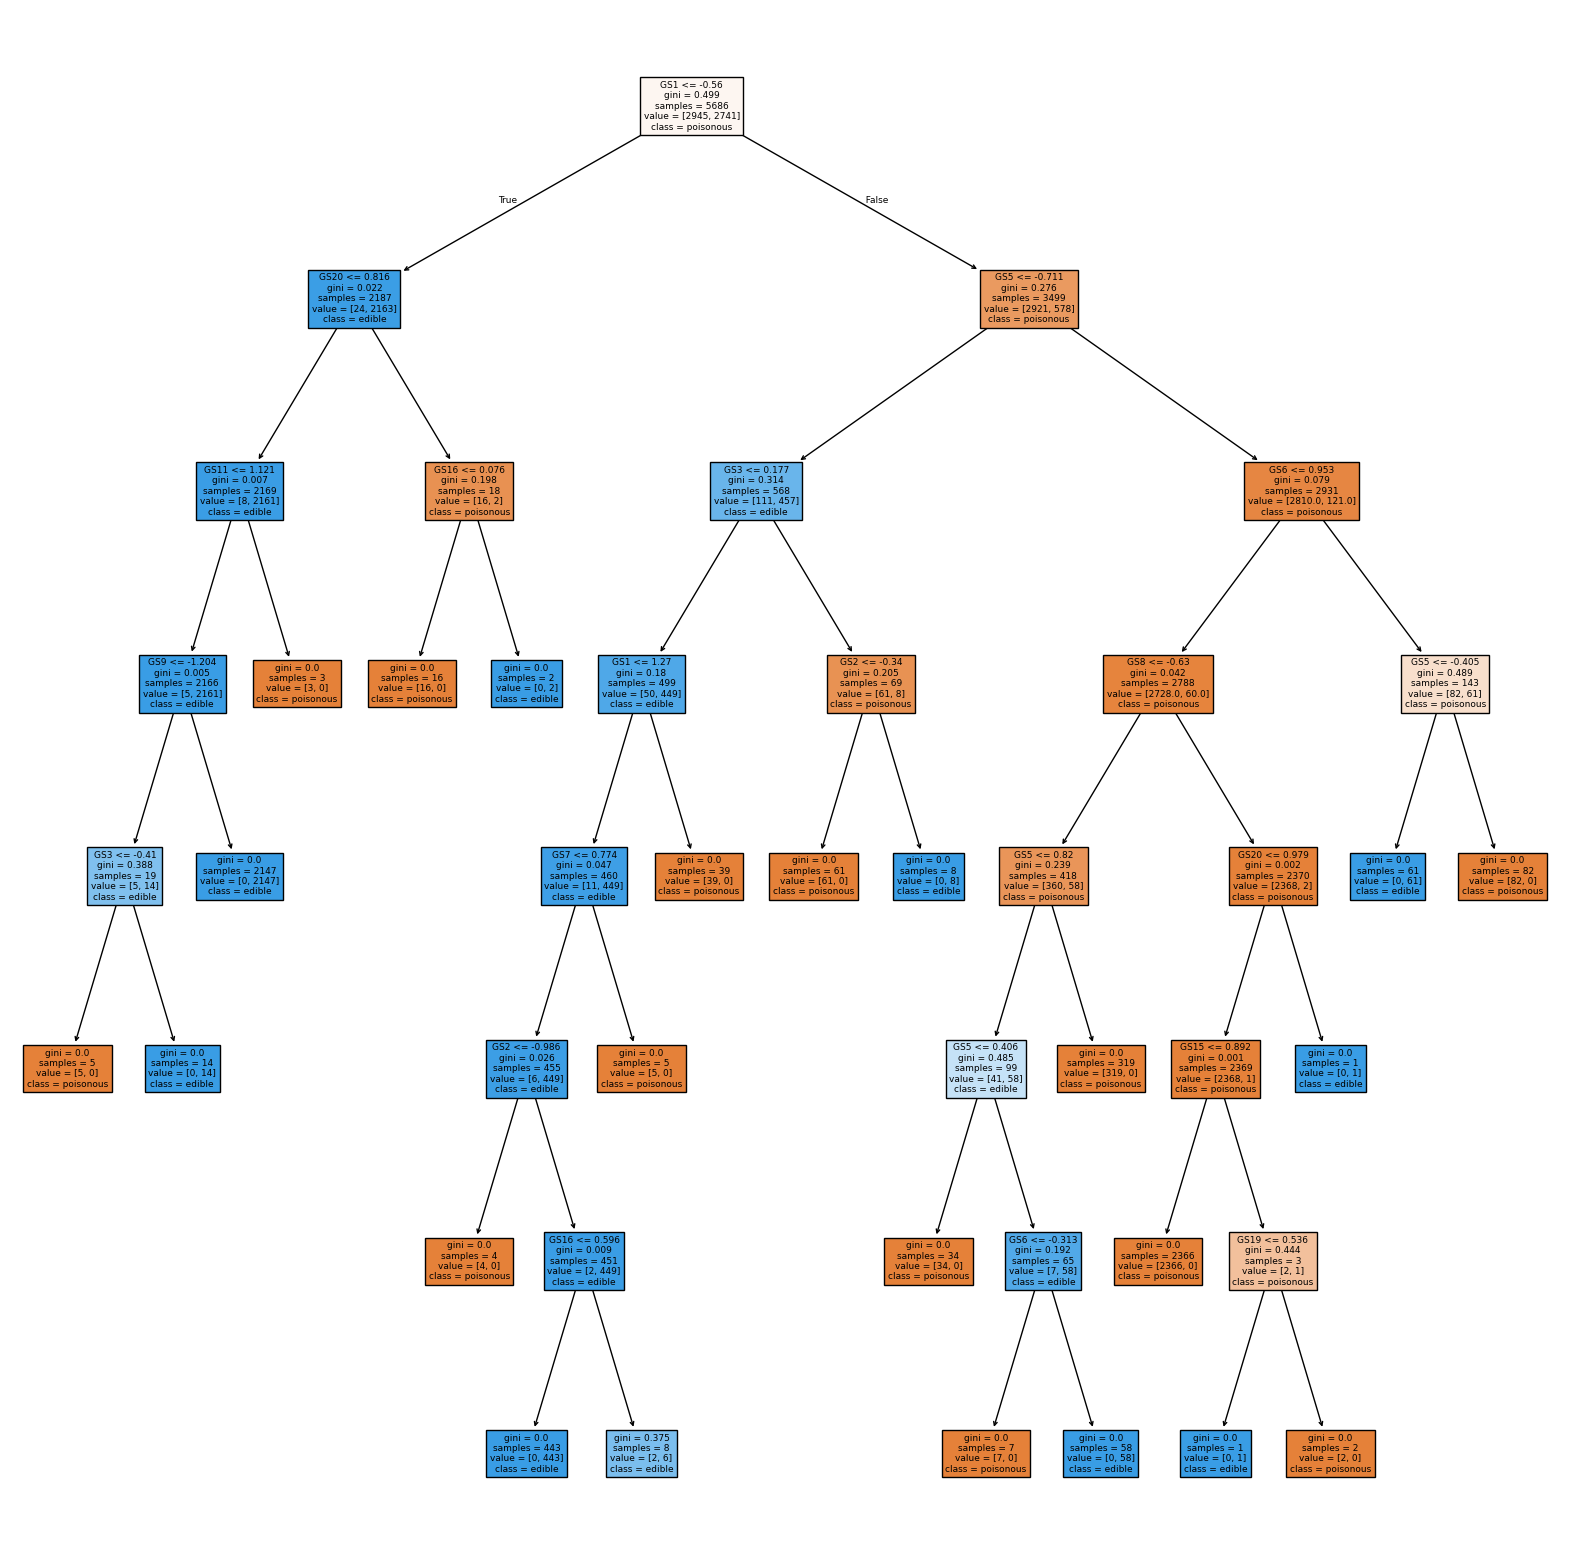

In [43]:
plt.figure(figsize=(20,20))
tree.plot_tree(dtree, feature_names=X_pca_onehot.columns, class_names=y_pca_onehot.unique(), filled=True)
plt.show()

Macierz błędów

<Figure size 1200x800 with 0 Axes>

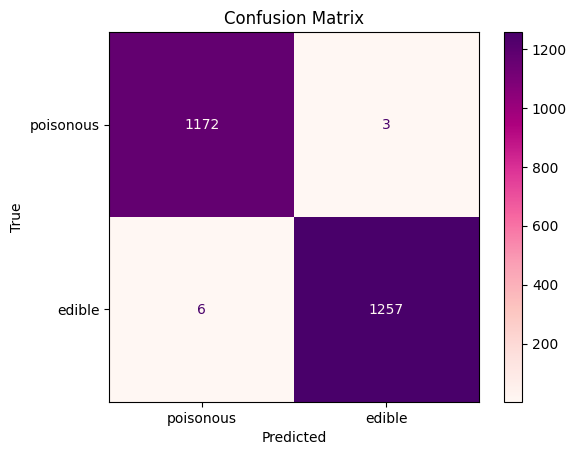

In [44]:
class_labels = y_pca_onehot.unique()
cm = confusion_matrix(y_test, pred, labels=class_labels)
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
disp.plot(values_format='d', cmap='RdPu')
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Podsumowanie procesu modelowania klasyfikatora

<p>
    Różnice między skutecznością wykorzystania wcześniej przygotowanych danych mieściły się w zakresie 0.1% - 3%. Do finalnego modelu zastosowano zbiór o najwyższych wynikach poprawności według samodzielnego obliczenia accuracy i wyników Grid Search.
</p>

<p>
    Parametry utworzonego modelu drzewa decyzyjnego:
</p>

<ul>
    <li>Zbiór danych - <strong>PCA + One-Hot Encoding</strong></li>
    <li>Głębokość drzewa - <strong>7</strong></li>
    <li>Kryterium - <strong>Gini</strong></li>
</ul>

<p>
    Wyniki modelu:
</p>

<ul>
    <li>Accuracy - <strong>99.6%</strong></li>
    <li>Precision - <strong>99% - 100%</strong></li>
    <li>Recall - <strong>100%</strong></li>
</ul>

<p>
    Klasyfikator częściej zwraca False negatives niż False Positives, co w przypadku klasyfikatora jadalności grzybów jest preferowane.
</p>

# 5. Wykrywanie reguł asocjacyjnych

In [33]:
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

<p>
       Ustawienie progu wsparcia (support) i zaufania (confidence).
</p>

In [2]:
min_support = 0.2
min_confidence = 0.5

<p>
    Wyznaczenie zbiorów częstych w zbiorze danych zapisanym w postaci binarnej z wykorzystaniem algorytmu Apriori. Do dalszej analizy zostaną wykorzystane jedynie kombinacje, które występują w co najmniej wcześniej określonym odsetku transakcji (min_support).
</p>

In [27]:
frequent_itemsets = apriori(mushrooms_onehot.drop(columns=["class"]), min_support=min_support, use_colnames=True)
print("Zbiory częste: ")
print(frequent_itemsets)

C:\Users\vekac\AppData\Local\Programs\Python\Python39\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Zbiory częste: 
        support                                           itemsets
0      0.387986                                   (cap-shape_flat)
1      0.450025                                 (cap-shape_convex)
2      0.285574                              (cap-surface_fibrous)
3      0.314623                               (cap-surface_smooth)
4      0.399311                                (cap-surface_scaly)
...         ...                                                ...
28212  0.212703  (ring-type_pendant, stalk-surface-below-ring_s...
28213  0.212703  (ring-type_pendant, gill-spacing_close, stalk-...
28214  0.212703  (ring-type_pendant, gill-spacing_close, stalk-...
28215  0.212703  (ring-type_pendant, gill-spacing_close, stalk-...
28216  0.212703  (ring-type_pendant, gill-spacing_close, stalk-...

[28217 rows x 2 columns]


<p>
    Generowanie reguł asocjacyjnych z wcześniej znalezionych zbiorów częstych. Reguły są filtrowane według minimalnego poziomu zaufania (confidence). Poniższy wynik pokazuje powiązania (antecedents -> consequents), jak i poziom wsparcia (support) oraz jak silne jest to powiązanie (lift).
</p>

In [28]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
print(rules[['antecedents', 'consequents', 'support', 'lift']])

C:\Users\vekac\AppData\Local\Programs\Python\Python39\lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


                                               antecedents  \
0                                         (cap-shape_flat)   
1                                         (cap-shape_flat)   
2                                         (cap-shape_flat)   
3                                         (cap-shape_flat)   
4                                         (cap-shape_flat)   
...                                                    ...   
5802693  (stalk-surface-above-ring_smooth, bruises_brui...   
5802694   (stalk-surface-above-ring_smooth, habitat_woods)   
5802695                   (bruises_bruises, habitat_woods)   
5802696                                  (bruises_bruises)   
5802697                                    (habitat_woods)   

                                               consequents   support      lift  
0                                             (bruises_no)  0.215903  0.952144  
1                                   (gill-attachment_free)  0.381339  1.008949  
2           

<p>
    Wizualna interpretacja uzyskanych reguł.
</p>

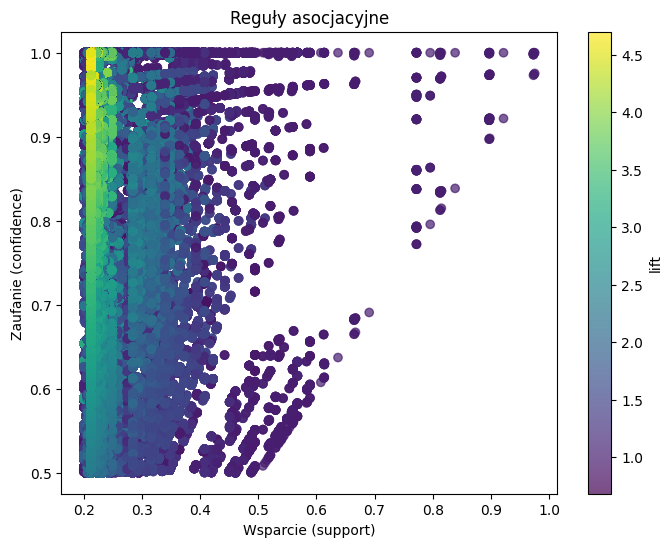

In [29]:
plt.figure(figsize = (8,6))
scatter = plt.scatter(rules['support'], rules['confidence'], c = rules['lift'], cmap = "viridis", alpha = 0.7)
plt.colorbar(scatter, label="lift")
plt.xlabel("Wsparcie (support)")
plt.ylabel("Zaufanie (confidence)")
plt.title("Reguły asocjacyjne")
plt.show()

<p>
    Na podstawie powyższego wykresu możemy zauważyć, że według miary atrakcyjności reguł asocjacyjnych (lift), największe powiązanie - na poziomie 4.7 - mają reguły występujące w około 21% przypadków, z wysokim poziomem zaufania (95%-100%), co oznacza że prawie za każdym razem, gdy pojawiają się antecedents, pojawiają się też consequents. Ze wzrostem support obserwujemy tendencję do spadku wartości lift – powiązania stają się mniej wyraźne, jednak nadal pozostają powyżej 1, co wskazuje, że zależność między elementami występuje i jest istotna, choć nie tak silna jak w przypadku topowych reguł o niższym support.
</p>

<p>
    Wyświetlenie 10 najlepszych reguł.
</p>

In [31]:
pd.set_option('display.max_colwidth', None)
best_rules = rules.sort_values(by='lift', ascending=False)
print(best_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

                                                                                                    antecedents  \
4247136                                       (habitat_woods, stalk-surface-below-ring_smooth, gill-size_broad)   
5280789        (gill-color_buff, ring-number_one, veil-color_white, ring-type_evanescent, gill-attachment_free)   
5280792      (gill-color_buff, ring-number_one, ring-type_evanescent, population_several, gill-attachment_free)   
5280795     (gill-color_buff, veil-color_white, ring-type_evanescent, population_several, gill-attachment_free)   
5280800           (ring-type_evanescent, veil-type_partial, gill-size_narrow, bruises_no, stalk-shape_tapering)   
4246709  (stalk-surface-below-ring_smooth, gill-size_broad, veil-color_white, ring-type_pendant, habitat_woods)   
4246677                 (ring-type_pendant, gill-spacing_close, odor_none, ring-number_one, stalk-root_bulbous)   
4246918                    (gill-size_broad, habitat_woods, stalk-surface-below-

<p>
    Interpretacja topowej reguły (4247136): 
    Jeśli grzyb rośnie w lesie, ma gładką powierzchnię trzonu i szerokie blaszki, to praktycznie zawsze będzie miał także blaszki blisko siebie, częściową osłonę , bulwiasty korzeń, brak zapachu, jeden pierścień, białą osłonę i pierścień typu pendant.
</p>

# Podsumowanie analizy reguł asocjacji

<p>
    W analizie reguł asocjacyjnych przyjęto próg wsparcia (support) na poziomie 0.2 i zaufania (confidence) na 0.5. Wyższe progi support i confidence powodowały eliminację reguł o bardzo dużych wartościach lift.
</p>

<p>
    Analiza wykazała, że najatrykcyjniejsze reguły pojawiają się w około 21% przypadków, z pełnym poziomem zaufania (confidence = 100%) i wysokim lift (4.7), co wskazuje, że określone kombinacje cech grzybów bardzo często występują razem i można je uznać za mocno powiązane. Wraz ze wzrostem support zauważamy spadek wartości lift, ale reguły nadal zachowują istotne powiązania (lift > 1).
</p>

<p>
    Obserwacje wynikające z topowych reguł:
    <ul>
    <li>Silne powiązania między cechami morfologicznymi</li>
    <li>Cechy środowiskowe powiązane z cechami fizycznymi</li>
    <li>Standardowe kombinacje cech: blaszki blisko siebie, częściowa osłona, bulwiasty korzeń,jeden pierścień, biała osłona </li>
</ul>
</p>
